# 보완 할 것
### 지금 모델은 메인 후보로 두고 비교 모델 2개는 꼭 돌려보기
- 보고서에서 XGBClassifier만 쓰는 것보다
```
Logistic Regression
RandomForest
XGBClassifier
```
- 이렇게 비교하고 XGBClassifier가 가장 적합했다고 말하는 게 훨씬 설득력 있으니까
- 만약 이 모델을 쓰게된다면 왜 XGBoost를 최종모델로 골랐는지 근거 꼭 만들기

### Threshold 0.5말고 위험도 기준을 조정해보기
- 지금은 0.5 이상이면 사고발생으로 했음
- 목적: 정확히 사고 / 비사고 분류보다 위험 상위 구간 선별
- threshold별로 비교해보기
```
for threshold in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_proba >= threshold).astype(int)
    
    print("Threshold:", threshold)
    print("Recall:", recall_score(y_test, y_pred_t))
    print("F1:", f1_score(y_test, y_pred_t))
    print(confusion_matrix(y_test, y_pred_t))
    print("-" * 40)
```
- 정책 목적상 Recall을 우선 고려해 threshold를 설정했다 이런식으로 보고서에 쓰기

### Top 5%, Top 10%, Top 20% Recall 같이 보기
- 지금 Top 10%만 봤는데 이걸 더 확장하면 정책 우선순위 설명이 좋아짐
```
for ratio in [0.05, 0.10, 0.20]:
    top_n = int(len(test_result) * ratio)
    top_risk = test_result.sort_values('risk_proba', ascending=False).head(top_n)
    
    top_recall = top_risk['actual'].sum() / test_result['actual'].sum()
    
    print(f"Top {int(ratio*100)}% Recall:", top_recall)
    print("포함된 실제 사고 수:", top_risk['actual'].sum())
    print("-" * 40)
```
- 이거 공모전에서 진짜 좋대!!!
- 상위 10%만 관리해도 사고 발생 지점 64.8% 포함 이런식으로 말할 수 있으니까!!

# 결론
- 지금 모델 버릴 필요 없고 메인 모델로 가져가도 될거같다고 지피티는 말함
- 최종모델은 아니고
```
1차: XGBClassifier 메인 모델 완성
2차: Logistic/RandomForest 비교
3차: threshold별 성능 비교
4차: Top 5/10/20% Recall 비교
5차: 최종 Risk Score 기반 위험역/위험유형 도출
```
- 이런식으로 가면서 점점 더 탄탄하게 만들기

### 내가 앙상블도 필요할 거 같냐고 물어봤는데
- 앙상블까지는 지금 단계에서 굳이 안 해도될거 같다고 하네
- 공모전에서는 복잡한 앙상블 보다 설명 가능하고 정책으로 연결되는 모델이 더 중요해서
- 지금은 XGBClassifier + 비교모델 + Top-K Recall + 변수중요도/SHAP 쪽이 더 좋은듯?!
- 더 고민해보기!!


# 민영 추가
- XGBClassifier 돌릴때 하이퍼파라미터 최적값 찾는 코드 넣으면 어떨지
- 마지막 코드에서 혼잡지수가 왜 1.369633e-01 형태로 나오지??
- 로지스틱, 랜덤포레스트는 낼 우리 만나서 같이 돌려보자

# 기본

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 라이브러리 설치
!pip install xgboost -q

In [ ]:
# 라이브러리
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

from xgboost import XGBClassifier

In [ ]:
# csv 파일 불러오기
file_path = '/content/drive/MyDrive/서울시 빅데이터 공모전/data/processed/df_final_all_preprocessed.csv'
df = pd.read_csv(file_path, encoding='utf-8-sig', low_memory=False)
df.head()

,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


In [ ]:
# 데이터 기본 확인
print(df.shape)
print(df.columns.tolist())
print(df.isna().sum())
df.head()

(73964, 15)
['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량']
사용월               0
호선명               0
time_group        0
혼잡                0
역명_clean          0
구조평균              0
구조최소              0
구조최대              0
사고수               0
유입                0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
환승량               0
dtype: int64


,사용월,호선명,time_group,혼잡,역명_clean,구조평균,구조최소,구조최대,사고수,유입,child_pop_sum,youth_pop_sum,middle_pop_sum,elder_pop_sum,환승량
0,202101,1호선,기타,85553,동대문,12.6625,10.0,19.0,0,109.158033,2.371445,28.573098,38.102411,40.111080,48535.333333
1,202101,1호선,낮시간,227205,동대문,12.6625,10.0,19.0,0,89.818268,4.140349,13.174589,27.672827,44.830502,48535.333333
2,202101,1호선,출근시간,50184,동대문,12.6625,10.0,19.0,0,57.970107,1.030731,8.346038,19.046191,29.547147,48535.333333
3,202101,1호선,퇴근시간,132625,동대문,12.6625,10.0,19.0,0,95.624161,3.856447,21.486049,28.811206,41.470459,48535.333333
4,202101,1호선,기타,34309,동묘앞,6.8375,3.0,12.0,0,70.195318,2.336531,25.357979,22.212263,20.288545,45053.333333


# 사고수 -> 사고발생 여부로 변환

In [ ]:
# 사고발생 여부 타깃 변수 생성
# 사고수 > 0 이면 실제 사고가 발생한 경우이므로 1
# 사고수 = 0 이면 사고가 발생하지 않은 경우이므로 0
# 즉, 사고 "건수" 예측이 아니라 사고 "발생 여부"를 예측하는 이진분류 문제로 변환

df['사고발생'] = (df['사고수'] > 0).astype(int)

# 사고발생/미발생 데이터 개수 확인
print(df['사고발생'].value_counts())

# 사고발생/미발생 비율 확인
# 클래스 불균형 정도를 확인하기 위한 단계
print(df['사고발생'].value_counts(normalize=True))

사고발생
0    73152
1      812
Name: count, dtype: int64
사고발생
0    0.989022
1    0.010978
Name: proportion, dtype: float64


In [ ]:
# 컬럼명 확인
print(df.columns.tolist())

['사용월', '호선명', 'time_group', '혼잡', '역명_clean', '구조평균', '구조최소', '구조최대', '사고수', '유입', 'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum', '환승량', '사고발생']


In [ ]:
# 숫자형 변수 전처리
# 모델 학습에 사용할 주요 변수들을 숫자형으로 변환하는 단계
# CSV를 불러오면 숫자가 문자열로 들어오거나, 쉼표(,)가 포함되어 있을 수 있기 때문에 정리 필요

num_cols = [
    '혼잡', '유입', '구조평균', '구조최소', '구조최대',
    '환승량',
    'child_pop_sum', 'youth_pop_sum', 'middle_pop_sum', 'elder_pop_sum'
]

for col in num_cols:
    df[col] = (
        df[col]
        .astype(str)                         # 문자열로 변환
        .str.replace(',', '', regex=False)   # 숫자 안의 쉼표 제거
        .str.strip()                         # 앞뒤 공백 제거
    )

    # 숫자로 변환
    # 변환이 안 되는 값은 NaN으로 처리
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 변환 과정에서 생긴 결측치 NaN을 각 컬럼의 중앙값으로 대체
# 평균보다 중앙값이 이상치 영향을 덜 받아서 안전함
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 결측치가 남아 있는지 확인
print(df[num_cols].isna().sum())

혼잡                0
유입                0
구조평균              0
구조최소              0
구조최대              0
환승량               0
child_pop_sum     0
youth_pop_sum     0
middle_pop_sum    0
elder_pop_sum     0
dtype: int64


In [ ]:
# 지수 변수 생성
# 혼잡, 유입, 구조, 환승량은 단위와 크기가 서로 다르기 때문에
# 모델이 비교하기 쉽도록 0~1 범위의 지수로 정규화하는 단계

# 혼잡 값 중 비정상적으로 큰 이상값은 NaN으로 처리
df.loc[df['혼잡'] > 10_000_000, '혼잡'] = np.nan

# 이상값 처리로 생긴 결측치는 중앙값으로 대체
df['혼잡'] = df['혼잡'].fillna(df['혼잡'].median())

# 각 변수를 최댓값으로 나누어 0~1 범위의 지수로 변환
df['혼잡지수'] = df['혼잡'] / df['혼잡'].max()
df['유입지수'] = df['유입'] / df['유입'].max()
df['구조지수'] = df['구조최대'] / df['구조최대'].max()
df['환승지수'] = df['환승량'] / df['환승량'].max()

# 역 주변 유입 인구의 전체 규모 계산
df['전체유입인구'] = (
    df['child_pop_sum'] +
    df['youth_pop_sum'] +
    df['middle_pop_sum'] +
    df['elder_pop_sum']
)

# 연령대별 취약계층 비율 변수 생성
# 고령층과 아동은 사고 위험 대응에서 중요한 정책 대상이 될 수 있음
# 1e-6은 전체유입인구가 0일 때 나누기 오류를 방지하기 위한 아주 작은 값
df['고령층비율'] = df['elder_pop_sum'] / (df['전체유입인구'] + 1e-6)
df['아동비율'] = df['child_pop_sum'] / (df['전체유입인구'] + 1e-6)

# 생성된 지수 변수들의 분포 확인
df[['혼잡지수', '유입지수', '구조지수', '환승지수', '고령층비율', '아동비율']].describe()

,혼잡지수,유입지수,구조지수,환승지수,고령층비율,아동비율
count,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000,73964.000000
mean,0.072063,0.422312,0.411987,0.102789,0.253972,0.072303
std,0.069125,0.172835,0.152661,0.183503,0.089719,0.065628
min,0.000000,0.000000,0.178571,0.000000,0.000000,0.000000
25%,0.029293,0.294796,0.321429,0.000000,0.193796,0.035012
50%,0.051901,0.420421,0.382143,0.000000,0.249059,0.054296
75%,0.089952,0.538274,0.500000,0.154406,0.312207,0.084309
max,1.000000,1.000000,1.000000,1.000000,0.545968,0.479915


In [ ]:
# time_group 원핫인코딩
# time_group은 '출근시간', '퇴근시간', '낮시간' 같은 문자형 범주 변수이기 때문에
# XGBoost 모델에 넣기 위해 0/1 형태의 숫자 변수로 변환

df_model = pd.get_dummies(
    df,
    columns=['time_group'],
    drop_first=False
)

# 원핫인코딩으로 생성된 시간대 컬럼만 따로 추출
time_cols = [col for col in df_model.columns if col.startswith('time_group_')]

# 모델 학습에 사용할 최종 입력 변수 목록
# 혼잡, 유입, 구조, 환승, 취약계층 비율, 시간대 정보를 사용
feature_cols = [
    '혼잡지수',
    '유입지수',
    '구조지수',
    '환승지수',
    '고령층비율',
    '아동비율'
] + time_cols

# X: 모델이 사고발생 여부를 예측할 때 사용할 설명변수
X = df_model[feature_cols]

# y: 모델이 예측해야 하는 정답값
# 사고발생 여부 0/1
y = df_model['사고발생']

# 입력 데이터 크기 확인
print(X.shape)

# 사고발생/미발생 개수 확인
print(y.value_counts())

(73964, 10)
사고발생
0    73152
1      812
Name: count, dtype: int64


# train/test 분리
# 클래스 불균형 보정

In [ ]:
# train/test 데이터 분리
# 모델 학습에 사용할 데이터와 성능 평가에 사용할 데이터를 나누는 단계
# test_size=0.2 → 전체 데이터의 20%를 test 데이터로 사용
# stratify=y → 사고발생(1)과 사고미발생(0)의 비율이 train/test에 비슷하게 유지되도록 분리
# random_state=42 → 매번 같은 방식으로 데이터가 나뉘도록 고정
# 약 1.1%만 사고발생이라서 scale_pos_weight 해주기
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("train")
print(y_train.value_counts())

print("test")
print(y_test.value_counts())

print("scale_pos_weight:", scale_pos_weight)

train
사고발생
0    58521
1      650
Name: count, dtype: int64
test
사고발생
0    14631
1      162
Name: count, dtype: int64
scale_pos_weight: 90.0323076923077


# XGBoost Classifier 학습

In [ ]:
# XGBoost Classifier 학습
# 사고발생 여부(0/1)를 예측하는 메인 모델
# scale_pos_weight를 넣어서 사고발생 데이터가 적은 문제를 보정

from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=3,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_clf.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

# 성능 평가

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    recall_score,
    f1_score
)

# test 데이터에 대해 사고발생 확률 예측
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# 확률이 0.5 이상이면 사고발생 1로 분류
y_pred = (y_proba >= 0.5).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

# 해석
# Recall = 0.9259
# 실제 사고 발생 162개 중 150개를 잡음
# 사고 위험 예측에서는 매우 좋은 편!

# ROC-AUC = 0.9099
# 사고 / 비사고를 구분하는 전체 능력도 좋음

# 문제
# Precision = 0.0470
# F1-score = 0.0895
# PR-AUC = 0.1030
# 사고라고 예측한 것 중에 실제 사고는 적음
# 위험하다고 넓게 많이 잡는 모델임

# Confusion Matirx 해석
# 실제 사고 162개 중 150개 맞힘, 12개 놓침
# 실제 비사고 14631개 중 3039개를 사고 위험으로 잘못 예측

# 결론
# 현재 모델은 실제 사고 발생 지점을 대부분 탐지하는 데 강점이 있으나,
# 사고 위험 후보를 넓게 잡는 경향이 있다.
# 따라서 단순한 사고/비사고 분류기보다는,
# 예측확률을 활용한 위험도 점수화 및 위험 상위 구간 선별 모델로 활용하는 것이 적합하다.

Confusion Matrix
[[11592  3039]
 [   12   150]]

Classification Report
              precision    recall  f1-score   support

           0     0.9990    0.7923    0.8837     14631
           1     0.0470    0.9259    0.0895       162

    accuracy                         0.7938     14793
   macro avg     0.5230    0.8591    0.4866     14793
weighted avg     0.9885    0.7938    0.8750     14793

ROC-AUC: 0.9098894533929733
PR-AUC: 0.10296587011764771
Recall: 0.9259259259259259
F1-score: 0.08952551477170993


# Top 10% Recall 확인

## 여기까지 정리
```
Recall = 0.9259
ROC-AUC = 0.9099
Top 10% Recall = 0.6481
```
- 이건 사고 위험 후보를 잘 잡는 모델
- 특히 Top 10% 안에 실제 사고의 64.8%가 들어간 건 정책 우선순위 모델로 쓰기 좋음
- 다만 아직 최종 모델 확정은 아님
- 메인 후보 모델 1차 완성 정도

---

## 지금 상태 평가
- 모델 구조: 좋음
- 성능: 좋음 (Recall + Top10% Recall)
- 해석: 가능 (변수 중요도 확보)
- 공모전용: 매우 적합

In [ ]:
# Top 10% Recall 계산
# 모델이 예측한 Risk 확률 기준 상위 10% 구간 안에
# 실제 사고발생 지점이 얼마나 포함되는지 확인

test_result = X_test.copy()
test_result['actual'] = y_test.values
test_result['risk_proba'] = y_proba

top_n = int(len(test_result) * 0.1)

top_risk = test_result.sort_values('risk_proba', ascending=False).head(top_n)

top10_recall = top_risk['actual'].sum() / test_result['actual'].sum()

print("Top 10% Recall:", top10_recall)
print("Top 10% 안 실제 사고발생 수:", top_risk['actual'].sum())
print("전체 실제 사고발생 수:", test_result['actual'].sum())

# 해석
# Top 10% Recall = 0.6481
# 모델이 위험하다고 판단한 상위 10% 구간 안에 실제 사고 발생의 약 64.8%가 포함됨
# 전체 사고 162건 중 105건을 위험 상위 10% 안에서 잡아냄

# XGBClassifier의 예측확률을 Risk Score로 활용한 결과,
# 위험도 상위 10% 구간에서 실제 사고 발생 사례의 64.8%를 포함하였다.
# 이는 전체 역·시간대 중 일부 고위험 구간만 우선 관리하더라도
# 상당수의 사고 발생 지점을 선별할 수 있음을 의미한다.

Top 10% Recall: 0.6481481481481481
Top 10% 안 실제 사고발생 수: 105
전체 실제 사고발생 수: 162


# 변수 중요도 확인
-> 왜 위험하다고 판단했는지 설명

In [ ]:
# 변수 중요도 확인
# XGBoost가 사고발생 예측에 어떤 변수를 중요하게 사용했는지 확인

importance = pd.Series(
    xgb_clf.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

importance

# XGBClassifier가 사고발생 예측에서 가장 중요하게 본 변수: 환승지수
# 1위 환승지수: 0.473
# 2위 time_group_기타: 0.105
# 3위 구조지수: 0.076
# 4위 유입지수: 0.070
# 5위 혼잡지수: 0.070

# 문제
# 환승지수가 너무 압도적으로 큼

,0
환승지수,0.473298
time_group_기타,0.105118
구조지수,0.076290
유입지수,0.069893
혼잡지수,0.069671
고령층비율,0.060453
아동비율,0.047984
time_group_출근시간,0.043508
time_group_퇴근시간,0.030753
time_group_낮시간,0.023033


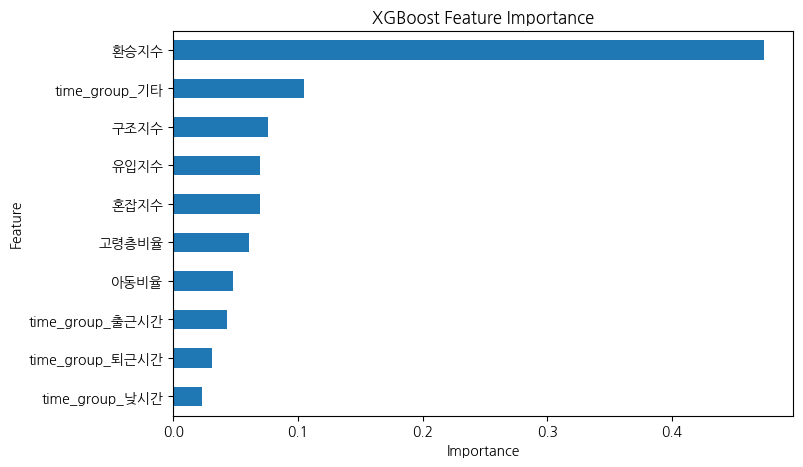

In [ ]:
# Colab 한글 폰트 설치
!apt-get -qq install fonts-nanum

# matplotlib 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

plt.rc('font', family='NanumGothic')
mpl.rcParams['axes.unicode_minus'] = False

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
importance.sort_values().plot(kind='barh')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# 환승지수 -> 압도적 1위
# 환승량 많은 역일수록 사고위험 증가
# 사람 흐름 복잡 -> 충돌, 발빠짐, 혼잡 위험 증가

# 시간대영향
# time_group_기타 > 출근 > 퇴근 > 낮
# 특정 시간대가 사고에 영향 있음
# 특히 비정형 시간대(기타)에서 변수 영향 큼

# 구조 + 유입 + 혼잡
# 같이 작용

# 취약계층 영향
# 고령층비율 > 아동비율
# 고령층 유입 많은 곳 = 사고위험 높음
# 정책적으로 의미 있음!!! -> 공모전 포인트

# 지하철 사고 위험은 환승, 시간대, 구조, 유입, 혼잡 요인이 복합적으로 작용하며,
# 특히 환승과 시간대 요인이 가장 큰 영향을 미치는 것으로 나타났다.

# 문제
# 환승지수 너무 크게 나오는게 괜찮?
# -> 괜찮음
# 근데 환승이 원인이다 이렇게 쓰면 안되고
# 환승 관련 변수의 설명력이 높게 나타났다라고 하기!!

# Risk Score 붙이기

In [ ]:
# XGBClassifier의 사고발생 예측확률을 Risk Score로 변환
# Risk는 0~1 사이의 사고발생 예측확률
# Risk_Score는 해석하기 쉽게 0~100점으로 변환한 위험도 점수

df_model['Risk'] = xgb_clf.predict_proba(X)[:, 1]
df_model['Risk_Score'] = df_model['Risk'] * 100

# df_model에는 time_group이 원핫인코딩되어 원래 time_group 컬럼이 없음
# 따라서 여기서는 역명, 호선, Risk Score만 먼저 확인

df_model[['역명_clean', '호선명', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,0.641803,64.180260,0,0
1,동대문,1호선,0.789267,78.926704,0,0
2,동대문,1호선,0.717828,71.782837,0,0
3,동대문,1호선,0.756950,75.694984,0,0
4,동묘앞,1호선,0.319727,31.972736,0,0


In [ ]:
# 원본 df에도 Risk Score 붙이기
# df에는 time_group 컬럼이 남아 있으므로 역·호선·시간대별 위험도 확인 가능

df['Risk'] = df_model['Risk']
df['Risk_Score'] = df_model['Risk_Score']

df[['역명_clean', '호선명', 'time_group', 'Risk', 'Risk_Score', '사고수', '사고발생']].head()

,역명_clean,호선명,time_group,Risk,Risk_Score,사고수,사고발생
0,동대문,1호선,기타,0.641803,64.180260,0,0
1,동대문,1호선,낮시간,0.789267,78.926704,0,0
2,동대문,1호선,출근시간,0.717828,71.782837,0,0
3,동대문,1호선,퇴근시간,0.756950,75.694984,0,0
4,동묘앞,1호선,기타,0.319727,31.972736,0,0


In [ ]:
# 역·호선·시간대별 위험도 순위 생성
# 같은 역/호선/시간대가 여러 월에 존재할 수 있으므로 평균 Risk Score로 집계
# 사고수는 실제 사고 발생 규모를 보기 위해 합계로 집계

top_risk_station_time = (
    df
    .groupby(['역명_clean', '호선명', 'time_group'], as_index=False)
    .agg(
        Risk_Score=('Risk_Score', 'mean'),
        Risk=('Risk', 'mean'),
        사고수=('사고수', 'sum'),
        사고발생=('사고발생', 'max'),
        혼잡지수=('혼잡지수', 'mean'),
        유입지수=('유입지수', 'mean'),
        구조지수=('구조지수', 'mean'),
        환승지수=('환승지수', 'mean')
    )
    .sort_values('Risk_Score', ascending=False)
)

top_risk_station_time.head(20)

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수
1065,천호,5호선,낮시간,92.252655,0.922527,13,1,1.369633e-01,0.458068,0.500000,0.334561
1097,충무로,3호선,낮시간,91.520218,0.915202,8,1,1.239756e-05,0.227851,0.928571,0.528398
85,고속터미널,7호선,낮시간,91.325996,0.913260,13,1,1.237434e-01,0.225579,0.678571,0.699515
1101,충무로,4호선,낮시간,91.040421,0.910404,7,1,1.892837e-01,0.232864,0.696429,0.528398
521,사당,4호선,낮시간,90.739174,0.907392,8,1,1.584908e-01,0.353410,0.267857,0.597375
1011,종로3가,1호선,퇴근시간,90.711823,0.907118,5,1,1.429969e-01,0.373683,0.607143,0.604816
517,사당,2호선,낮시간,90.312683,0.903127,12,1,2.463075e-01,0.225071,0.357143,0.597375
519,사당,2호선,퇴근시간,89.688721,0.896887,11,1,2.543994e-01,0.238396,0.357143,0.597375
125,교대,2호선,낮시간,89.683426,0.896834,10,1,2.374247e-01,0.462908,0.342857,0.455004
523,사당,4호선,퇴근시간,89.394127,0.893941,10,1,1.373551e-01,0.377957,0.267857,0.597375


In [ ]:
# 위험 유형 분류
# 각 역·시간대에서 가장 높은 지수를 기준으로 위험 유형을 부여
# 예: 혼잡지수가 가장 높으면 혼잡형, 구조지수가 가장 높으면 구조형

def classify_risk_type(row):
    values = {
        '혼잡형': row['혼잡지수'],
        '유입형': row['유입지수'],
        '구조형': row['구조지수'],
        '환승형': row['환승지수']
    }
    return max(values, key=values.get)

top_risk_station_time['위험유형'] = top_risk_station_time.apply(classify_risk_type, axis=1)

top_risk_station_time.head(20)

# 위험도 상위 역·시간대 분석 결과, 천호 5호선 낮시간, 충무로 3호선 낮시간, 고속터미널 7호선 낮시간, 사당 4호선 낮시간 등이 높은 위험도를 보였다.
# 이들 구간은 실제 사고수도 높게 나타나 XGBClassifier 기반 Risk Score가 사고 다발 구간을 일정 부분 반영하고 있음을 확인하였다.
# 또한 위험 유형을 분류한 결과, 상위 위험 구간은 구조형과 환승형이 다수로 나타나 승강장 구조와 환승 동선 복잡도가 주요 위험 요인으로 작용할 가능성이 있음을 확인하였다.

,역명_clean,호선명,time_group,Risk_Score,Risk,사고수,사고발생,혼잡지수,유입지수,구조지수,환승지수,위험유형
1065,천호,5호선,낮시간,92.252655,0.922527,13,1,1.369633e-01,0.458068,0.500000,0.334561,구조형
1097,충무로,3호선,낮시간,91.520218,0.915202,8,1,1.239756e-05,0.227851,0.928571,0.528398,구조형
85,고속터미널,7호선,낮시간,91.325996,0.913260,13,1,1.237434e-01,0.225579,0.678571,0.699515,환승형
1101,충무로,4호선,낮시간,91.040421,0.910404,7,1,1.892837e-01,0.232864,0.696429,0.528398,구조형
521,사당,4호선,낮시간,90.739174,0.907392,8,1,1.584908e-01,0.353410,0.267857,0.597375,환승형
1011,종로3가,1호선,퇴근시간,90.711823,0.907118,5,1,1.429969e-01,0.373683,0.607143,0.604816,구조형
517,사당,2호선,낮시간,90.312683,0.903127,12,1,2.463075e-01,0.225071,0.357143,0.597375,환승형
519,사당,2호선,퇴근시간,89.688721,0.896887,11,1,2.543994e-01,0.238396,0.357143,0.597375,환승형
125,교대,2호선,낮시간,89.683426,0.896834,10,1,2.374247e-01,0.462908,0.342857,0.455004,유입형
523,사당,4호선,퇴근시간,89.394127,0.893941,10,1,1.373551e-01,0.377957,0.267857,0.597375,환승형
